In [1]:
import openmc
import numpy as np
import matplotlib.pyplot as plt
import os

from Geometry_methods import set_geom_fuel_shell, make_settings, set_mat, get_material_by_name


In [8]:
# Load materials from XML
#materials = openmc.Materials.from_xml("materials-finish.xml")

#Using fond materials 
#materials = results.export_to_materials(1)
# Collect all nuclides present
nuclides = []

materials = openmc.Materials.from_xml('materials.xml')
geom = openmc.Geometry.from_xml("geometry.xml")

mat = get_material_by_name("Fuel_CA_2",materials)
for nuclide, amount,_ in mat.nuclides:
    nuclides.append([nuclide,amount])

print(nuclides)

[['Li6', 3.650000000023911e-06], ['Li7', 0.36499634999999997], ['F19', 0.581], ['U234', 2.4181748076582763e-05], ['U235', 0.0027054561672799015], ['U236', 1.2392288720033942e-05], ['U238', 0.051257969795923466]]


/openmc_venv/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=7.
  warn(msg, IDWarning)
/openmc_venv/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=8.
  warn(msg, IDWarning)
/openmc_venv/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=9.
  warn(msg, IDWarning)
/openmc_venv/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=10.
  warn(msg, IDWarning)
/openmc_venv/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=11.
  warn(msg, IDWarning)
/openmc_venv/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=12.
  warn(msg, IDWarning)
/openmc_venv/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already ex

In [9]:
import openmc.data
import re
decay = openmc.data.Decay.from_endf("../endf-b-vii.1/decay/dec-094_Pu_239.endf")

def make_AZ_Str(AZ):
    #Makes sure that number has 3 digits as in endf files and turns the numbers into strings
    if AZ < 10:
        AZstr = f"00{AZ}"
    elif AZ < 100:
        AZstr = f"0{AZ}"
    else:
        AZstr = f"{AZ}"
    return AZstr

def has_alpha_decay(nuclide):
    #Checking if atoms have alpha decay
    nuclide_name=nuclide[0]
    Z, A, m =openmc.data.zam(nuclide_name)

    #Isolating the atomic symbol
    #print(nuclide_name)
    match = re.match(r"([A-Za-z]+)(\d+)(_)(m\d+)",nuclide_name)
    #print(match)
    m1=0
    if match == None:
        match = re.match(r"([A-Za-z]+)",nuclide_name)
        symbol =match.groups()[0]
    else:
        symbol, _,_ ,m1 =match.groups()

    #print(symbol,m1)
    Z = make_AZ_Str(Z)
    A = make_AZ_Str(A)
    #print(Z,symbol,A)
    try:
        if m1 != 0:
            dec = openmc.data.Decay.from_endf(f"../endf-b-vii.1/decay/dec-{Z}_{symbol}_{A}{m1}.endf")
        else:
            dec = openmc.data.Decay.from_endf(f"../endf-b-vii.1/decay/dec-{Z}_{symbol}_{A}.endf")
        for mode in dec.modes:
            if mode.modes[0] == "alpha":
                return True
        return False   
    except KeyError:
        print("Error")
        return False

#print(has_alpha_decay(nuclides[3]))        
alpha_nuclides = [nuc for nuc in nuclides if has_alpha_decay(nuc)]

print(alpha_nuclides)

[['U234', 2.4181748076582763e-05], ['U235', 0.0027054561672799015], ['U236', 1.2392288720033942e-05], ['U238', 0.051257969795923466]]


In [10]:
def alpha_decay_values_from_material(material,geom,cell_name,show_discarded=False):
    #Takes a material and returns the amount of alpha decay pr L
    result = []
    material_mass = 0
    material_cell = geom.get_cells_by_name(cell_name)[0]
    material_cell.fill = material
    try:
        material_cell.volume = material.volume
        print('material.volume: ',material.volume)
    except Exception as e:
        print(f'Error no material volume defined {e}')
    for nuclide_name, nuclide_amount_percent,_ in material.nuclides:
        print(nuclide_name, nuclide_amount_percent)
        Z, A, m =openmc.data.zam(nuclide_name)
        print(f'number of {nuclide_name} atoms {material_cell.atoms[nuclide_name]}')
        nuclide_amount = material_cell.atoms[nuclide_name]
        nuclide_mass = openmc.data.atomic_mass(nuclide_name)
        total_mass = nuclide_mass*nuclide_amount
        print('nuclide mass', nuclide_mass, 'total mass ',total_mass*1.6605402e-27)
        material_mass += total_mass
        
        #Isolating the atomic symbol
        match = re.match(r"([A-Za-z]+)(\d+)(_)(m\d+)",nuclide_name)
        #print(match)
        m1=0
        if match == None:
            match = re.match(r"([A-Za-z]+)",nuclide_name)
            symbol =match.groups()[0]
        else:
            symbol, _,_ ,m1 =match.groups()
    
        Z = make_AZ_Str(Z)
        A = make_AZ_Str(A)

        #Getting decay data from ground state or excited (m1)
        if m1 != 0:
            dec = openmc.data.Decay.from_endf(f"../endf-b-vii.1/decay/dec-{Z}_{symbol}_{A}{m1}.endf")
        else:
            dec = openmc.data.Decay.from_endf(f"../endf-b-vii.1/decay/dec-{Z}_{symbol}_{A}.endf")

        #Seeing if decay constant is possible to return
        try:
            decay_constant = dec.decay_constant.nominal_value #log(2)/half_life
        except ValueError as e:
            if show_discarded:
                print(f"Skipping {dec.nuclide['name']} amount: {nuclide_amount:.3g}: {e}")
                decay_constant = 0
        
        #Finding the spectra and calculating the activity
        if len(dec.spectra)!=0 and has_alpha_decay([nuclide_name]):
            alpha_data=dec.spectra['alpha']
            energies = [float(item['energy'].nominal_value) for item in alpha_data['discrete']] #can be continuous or discrete
            intensities  = [float(item['intensity'].nominal_value) for item in alpha_data['discrete']]

            activities = [decay_constant*nuclide_amount*intensity for intensity in intensities] #Calculation of activities
            result.append([nuclide_name,activities,energies])
        else:
            if show_discarded:
                activity=decay_constant*nuclide_amount
                print(dec.nuclide['name'],f"activity: {activity:.3g} has no alpha spectra")

    material_mass = material_mass*1.6605402e-27
    print(f'total mass of {cell_name} filled with {material.name} is {material_mass:.3g} kg which gives a density of {material_mass*1000/material_cell.volume:.3g} g/cm^3')
    return result, material_mass
fuel = get_material_by_name("Fuel_CA_2",materials)
#print(fuel)
alpha_spectra_data1,total_mass = alpha_decay_values_from_material(fuel,geom,'fuel')


#print([d[0] for d in alpha_spectra_data1])


material.volume:  60352.08927056231
Li6 3.650000000023911e-06
number of Li6 atoms 2.460509350080153e+22
nuclide mass 6.01512288742 total mass  0.00024576436840338206
Li7 0.36499634999999997
number of Li7 atoms 2.4604847449705335e+27
nuclide mass 7.01600343426 total mass  28.66552258633266
F19 0.581
number of F19 atoms 3.91659159558138e+27
nuclide mass 18.99840316207 total mass  123.55911275001034
U234 2.4181748076582763e-05
number of U234 atoms 1.630121020365065e+23
nuclide mass 234.040950296 total mass  0.0633521115130458
U235 0.0027054561672799015
number of U235 atoms 1.82378087555633e+25
nuclide mass 235.043928117 total mass  7.118214776746719
U236 1.2392288720033942e-05
number of U236 atoms 8.353792401188104e+22
nuclide mass 236.04556613 total mass  0.032743787973034906
U238 0.051257969795923466
number of U238 atoms 3.455362025977247e+26
nuclide mass 238.050786936 total mass  136.58800804592306
total mass of fuel filled with Fuel_CA_2 is 296 kg which gives a density of 4.91 g/cm^3


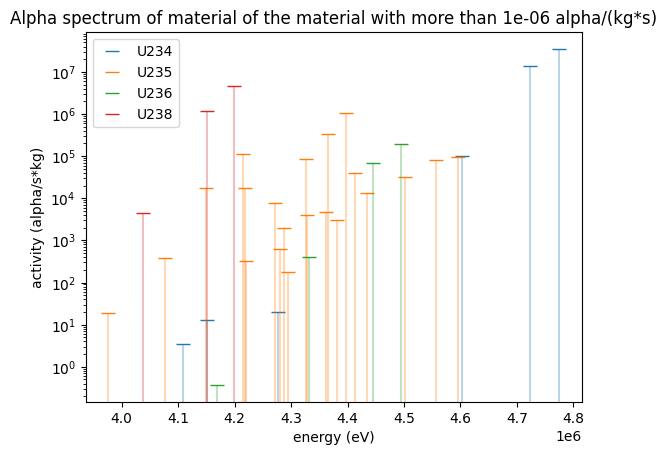

In [11]:
def plot_material_energy_spectra(alpha_spectra_data,total_mass,plot_threshold=1e-5,show_discarded=False):
    fig,ax = plt.subplots()
    
    ax.set_title(f"Alpha spectrum of material of the material with more than {plot_threshold} alpha/(kg*s)")
    ax.semilogy()
    ax.set_xlabel("energy (eV)")
    ax.set_ylabel("activity (alpha/s*kg)")
    for name, activities, energies  in alpha_spectra_data:
        activities_pr_kg = activities/total_mass
        if sum(activities_pr_kg) > plot_threshold:
            line, =ax.plot(energies, activities_pr_kg, "_", label=name,ms=10)
            ax.vlines(energies,[0]*len(energies),activities_pr_kg,line.get_color(),alpha=0.3)
        elif show_discarded:
            print(f'{name} with a total activity of {sum(activities_pr_kg):.2g} alpha/(kg*s) is not plotted')
    ax.legend()
    
plot_material_energy_spectra(alpha_spectra_data1,total_mass,plot_threshold=1e-6)